In [55]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pickle
sys.path.append('../src')
sys.path.append('../src/visualization')

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from minimal.mvp_visual import load_simulation_data, load_and_merge_consolidated
from minimal.mvp_visual import plot_opinion_trajectory, layout
from minimal.mvp_visual import get_simple_frequencies
from minimal.mvp_visual import plot_epidemic_heatmap_relative
from minimal.mvp_visual import plot_convergence_comparison








The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

In [ ]:
data_no_bots = load_simulation_data(
    data_dir=r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25\No_bots_sigma_experiment",
    file_pattern="results_ce*_th*_nb*",  # Include all 3 params
    param_names=["ce", "th", "nb"],      # Use all 3 param names
    date_suffix=None
)
data_no_bots = {(ce, nb): data for (ce, th, nb), data in data_no_bots.items()}
SIR_baseline = load_simulation_data(
    data_dir=r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25\SIR_1000_random",
    file_pattern="results_ce*_th*_nb*",  # Include all 3 params
    param_names=["ce", "th", "nb"],      # Use all 3 param names
    date_suffix=None
)
SIR_baseline_data = {(ce, nb): data for (ce, th, nb), data in SIR_baseline.items()}
SIRV_baseline = load_simulation_data(
    data_dir=r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25\SIRV_1000_random",
    file_pattern="results_ce*_th*_nb*",  # Include all 3 params
    param_names=["ce", "th", "nb"],      # Use all 3 param names
    date_suffix=None
)
SIRV_baseline = {(ce, nb): data for (ce, th, nb), data in SIRV_baseline.items()}

name = r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25"
folders = [os.path.join(name, f'SIRV_1000_random_{i}') for i in range(2, 7)]
print(folders)
merged_results = load_and_merge_consolidated(folders)

print(f"Merged {merged_results['n_replicas']} replicas")
print(f"Trajectory replicas: {len(merged_results['trajectory_replica_indices'])}")

# Save merged results
with open('merged_consolidated.pkl', 'wb') as f:
    pickle.dump(merged_results, f)

SIRV_baseline = merged_results


SIR_1000 = load_simulation_data(
    data_dir=r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25\SIR_1000",
    file_pattern="results_ce*_th*_nb*",  # Include all 3 params
    param_names=["ce", "th", "nb"],      # Use all 3 param names
    date_suffix=None
)
SIR_1000 = {(th, nb): data for (ce, th, nb), data in SIR_1000.items()}
SIRV_1000 = load_simulation_data(
    data_dir=r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25\SIRV_1000",
    file_pattern="results_ce*_th*_nb*",  # Include all 3 params
    param_names=["ce", "th", "nb"],      # Use all 3 param names
    date_suffix=None
)
SIRV_1000 = {(th, nb): data for (ce, th, nb), data in SIRV_1000.items()}

SIR_baseline = load_simulation_data(
    data_dir=r"C:\Users\nel_t\Documents\WORK\PROJECTS\Boosting Bots\data\09_07_25\SIR_1000_random",
    file_pattern="results_ce*_th*_nb*",  # Include all 3 params
    param_names=["ce", "th", "nb"],      # Use all 3 param names
    date_suffix=None
)
SIR_baseline_data = {(ce, nb): data for (ce, th, nb), data in SIR_baseline.items()}

Loaded: ce=0.05, th=0.0, nb=0.0
Loaded: ce=0.15, th=0.0, nb=0.0
Loaded: ce=0.1, th=0.0, nb=0.0
Loaded: ce=0.25, th=0.0, nb=0.0
Loaded: ce=0.2, th=0.0, nb=0.0
Loaded: ce=0.35, th=0.0, nb=0.0
Loaded: ce=0.3, th=0.0, nb=0.0
Loaded: ce=0.45, th=0.0, nb=0.0
Loaded: ce=0.4, th=0.0, nb=0.0
Loaded: ce=0.5, th=0.0, nb=0.0
Loaded: ce=0.0, th=0.0, nb=0.0

Loaded 11 files total
Loaded: ce=0.3, th=0.0, nb=0.0

Loaded 1 files total
['C:\\Users\\nel_t\\Documents\\WORK\\PROJECTS\\Boosting Bots\\data\\09_07_25\\SIRV_1000_random_2', 'C:\\Users\\nel_t\\Documents\\WORK\\PROJECTS\\Boosting Bots\\data\\09_07_25\\SIRV_1000_random_3', 'C:\\Users\\nel_t\\Documents\\WORK\\PROJECTS\\Boosting Bots\\data\\09_07_25\\SIRV_1000_random_4', 'C:\\Users\\nel_t\\Documents\\WORK\\PROJECTS\\Boosting Bots\\data\\09_07_25\\SIRV_1000_random_5', 'C:\\Users\\nel_t\\Documents\\WORK\\PROJECTS\\Boosting Bots\\data\\09_07_25\\SIRV_1000_random_6']
Merged 50 replicas
Trajectory replicas: 25
Loaded: ce=0.3, th=-0.2, nb=0.0
Loaded: ce=0

In [9]:
sigmas = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


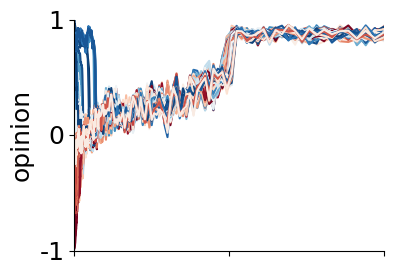

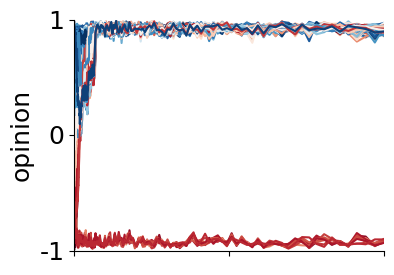

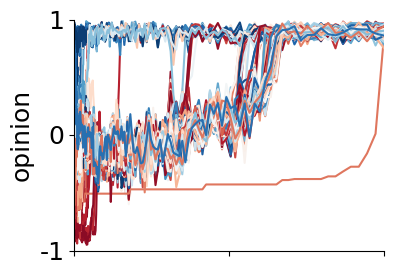

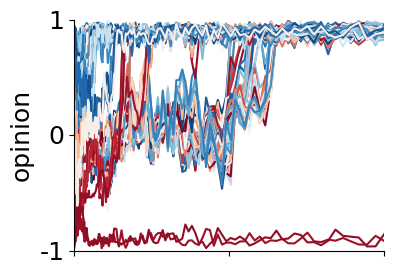

In [15]:
fig, ax = plt.subplots(figsize=(4, 3))
subdata = data_no_bots[(sigmas[5], 0.0)]
plot_opinion_trajectory(subdata, 0, ax = ax)
layout(fig, ax)
fig.savefig("OD_joint_extreme.pdf", dpi=300, bbox_inches="tight")
fig, ax = plt.subplots(figsize=(4, 3))
subdata = data_no_bots[(sigmas[-2], 0.0)]
plot_opinion_trajectory(subdata, 1, ax = ax)
layout(fig, ax)
fig.savefig("OD_disjoint_extreme.pdf", dpi=300, bbox_inches="tight")

## and random sorting:

fig, ax = plt.subplots(figsize=(4, 3))
subdata = SIR_baseline_data[(0.3, 0.0)]
plot_opinion_trajectory(subdata, 3, ax = ax)
layout(fig, ax, xlim = (0, 5000))
fig.savefig("baseline1.pdf", dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(4, 3))
subdata = SIR_baseline_data[(0.3, 0.0)]
plot_opinion_trajectory(subdata, 0, ax = ax)
layout(fig, ax, xlim = (0, 5000))
fig.savefig("baseline2.pdf", dpi=300, bbox_inches="tight")

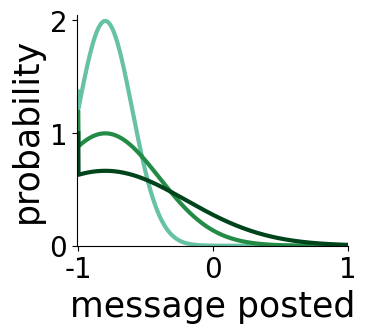

In [16]:
import numpy as np
from scipy.special import erf

def gaussian_distribution(x, mu, sigma):
    # Standard gaussian
    Y = np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    
    # Calculate clipped mass using error function
    # P(X < -1) = 0.5 * (1 + erf((-1 - mu) / (sigma * sqrt(2))))
    prob_below_minus1 = 0.5 * (1 + erf((-1 - mu) / (sigma * np.sqrt(2))))
    prob_above_plus1 = 0.5 * (1 - erf((1 - mu) / (sigma * np.sqrt(2))))
    
    # Add clipped mass to endpoints
    Y[0] += prob_below_minus1
    Y[-1] += prob_above_plus1
    
    return Y

colors = ['#66c2a4','#238b45','#00441b']
x = np.linspace(-1, 1, 1000)

fig, ax = plt.subplots(figsize=(3.5, 3))
ax.plot(x, gaussian_distribution(x, -0.8, 0.2), linewidth=3, color=colors[0])
ax.plot(x, gaussian_distribution(x, -0.8, 0.4), linewidth=3, color=colors[1])
ax.plot(x, gaussian_distribution(x, -0.8, 0.6), linewidth=3, color=colors[2])



# remove top and left spines:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([0, 1, 2])
ax.set_xlabel("message posted", fontsize=25)
ax.set_ylabel("probability", fontsize=25)
ax.set_xlim(-1.01, 1)
ax.set_ylim(0, 2.05)
ax.set_xticklabels([-1, 0, 1], fontsize=20)
ax.set_yticklabels([0, 1, 2], fontsize=20)




fig.savefig("gaussian_distribution.pdf", dpi=300, bbox_inches="tight")


In [17]:
thresholds = [-0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8]
n_bots =  [0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32, 64]

In [19]:
extreme_negative = np.zeros((len(thresholds), len(n_bots)))
extreme_positive = np.zeros((len(thresholds), len(n_bots)))
extreme_polarization = np.zeros((len(thresholds), len(n_bots)))

BULK = SIR_1000

for i, th in enumerate(thresholds):
    for j, nb in enumerate(n_bots):
        subdata = BULK[(th, nb)]
        frequencies = get_simple_frequencies(subdata)
        extreme_negative[i, j] = frequencies[1]
        extreme_positive[i, j] = frequencies[2]
        extreme_polarization[i, j] = frequencies[3]

Restrictive Classification:
Extremely negative  : 34 (34.0%)
Extremely positive  :  0 ( 0.0%)
Extremely extremist :  8 ( 8.0%)
Something else      : 58 (58.0%)

Total: 100 replicas

Thresholds:
  Extremely negative: >80% below -0.8
  Extremely positive: >80% above +0.8
  Extremely extremist: >10% above +0.8, >10% below -0.8, <20% in middle
Restrictive Classification:
Extremely negative  : 37 (37.0%)
Extremely positive  :  0 ( 0.0%)
Extremely extremist : 10 (10.0%)
Something else      : 53 (53.0%)

Total: 100 replicas

Thresholds:
  Extremely negative: >80% below -0.8
  Extremely positive: >80% above +0.8
  Extremely extremist: >10% above +0.8, >10% below -0.8, <20% in middle
Restrictive Classification:
Extremely negative  : 40 (40.0%)
Extremely positive  :  0 ( 0.0%)
Extremely extremist : 14 (14.0%)
Something else      : 46 (46.0%)

Total: 100 replicas

Thresholds:
  Extremely negative: >80% below -0.8
  Extremely positive: >80% above +0.8
  Extremely extremist: >10% above +0.8, >10% b

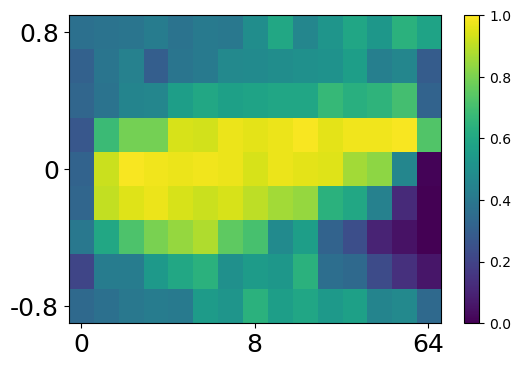

In [53]:
x_tick_indices = np.arange(0, len(thresholds), 4)  
y_tick_indices = np.arange(0, len(n_bots), 7)      

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(np.flipud(extreme_negative), cmap="viridis", vmin=0, vmax=1, aspect="auto")

# Fix the tick assignment - y should correspond to thresholds, x to n_bots
ax.set_yticks(np.flip(x_tick_indices))  # y-axis shows thresholds (flipped due to flipud)
ax.set_xticks(y_tick_indices)           # x-axis shows n_bots
ax.set_yticklabels([thresholds[i] for i in x_tick_indices], fontsize=18)
ax.set_xticklabels([n_bots[i] for i in y_tick_indices], fontsize=18)

# Proper colorbar
cbar = fig.colorbar(im, ax=ax)

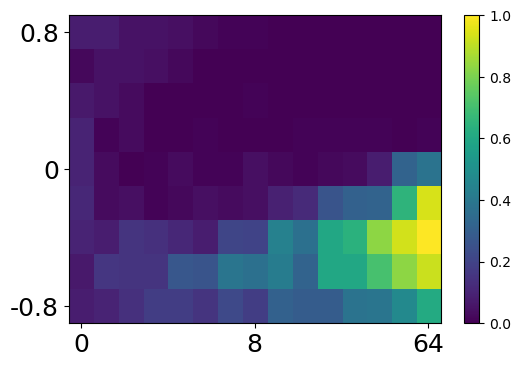

In [54]:
x_tick_indices = np.arange(0, len(thresholds), 4)  
y_tick_indices = np.arange(0, len(n_bots), 7)      

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(np.flipud(extreme_polarization), cmap="viridis", vmin=0, vmax=1, aspect="auto")

# Fix the tick assignment - y should correspond to thresholds, x to n_bots
ax.set_yticks(np.flip(x_tick_indices))  # y-axis shows thresholds (flipped due to flipud)
ax.set_xticks(y_tick_indices)           # x-axis shows n_bots
ax.set_yticklabels([thresholds[i] for i in x_tick_indices], fontsize=18)
ax.set_xticklabels([n_bots[i] for i in y_tick_indices], fontsize=18)

# Proper colorbar
cbar = fig.colorbar(im, ax=ax)

[Text(1, 0.0, '0'), Text(1, 0.5, '0.5'), Text(1, 1.0, '1')]

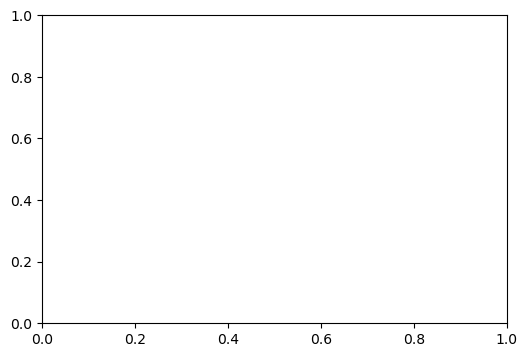

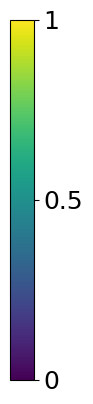

In [24]:
# plot a simple colorbar with no other data and 3 ticks

fig, ax = plt.subplots(figsize=(6, 4))
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(1.2, 4))
fig.subplots_adjust(left=0.4, right=0.7)
fig.delaxes(ax)

norm = Normalize(vmin=0, vmax=1)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
    cax=fig.add_axes([0.4, 0.05, 0.2, 0.9]),
    ticks=[0, 0.5, 1]
)
cbar.ax.set_yticklabels(['0', '0.5', '1'], fontsize=18)


# save the colorbar as a separate figure
#fig.savefig("colorbar_only.pdf", dpi=300, bbox_inches="tight")

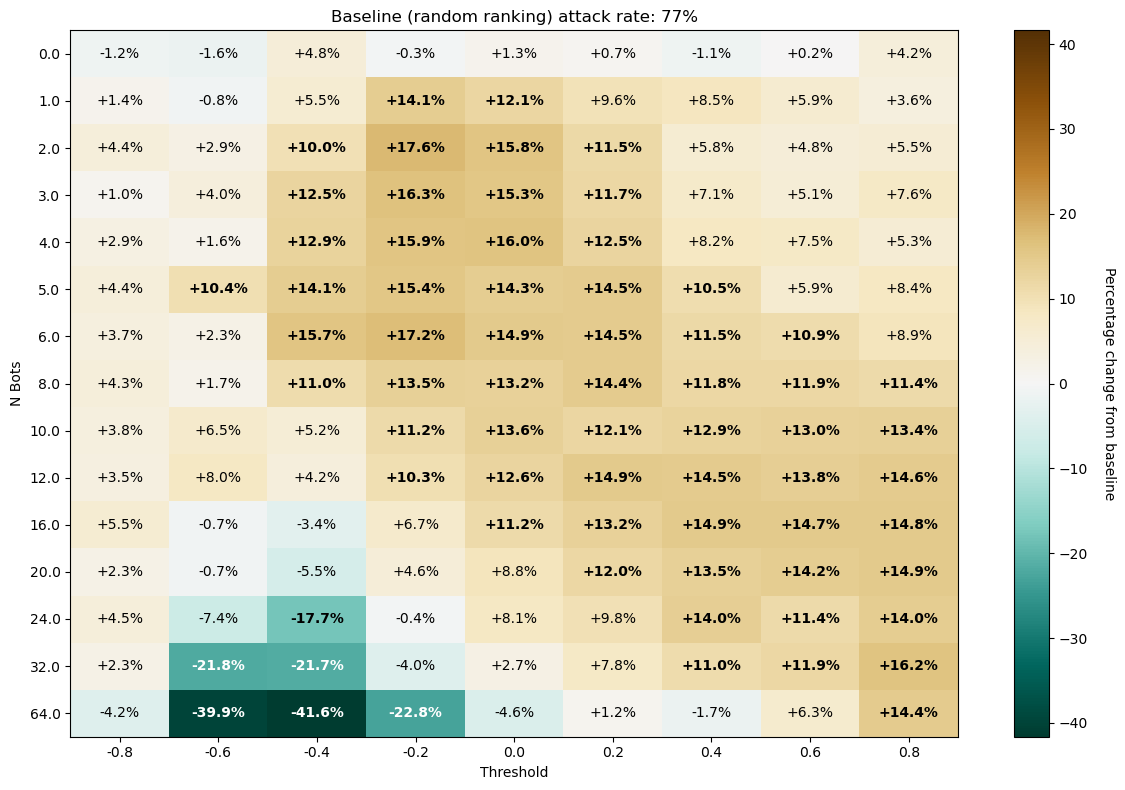

In [39]:
fig, ax, diffs, baseline = plot_attack_rate_comparison(SIR_1000, SIR_baseline_data)

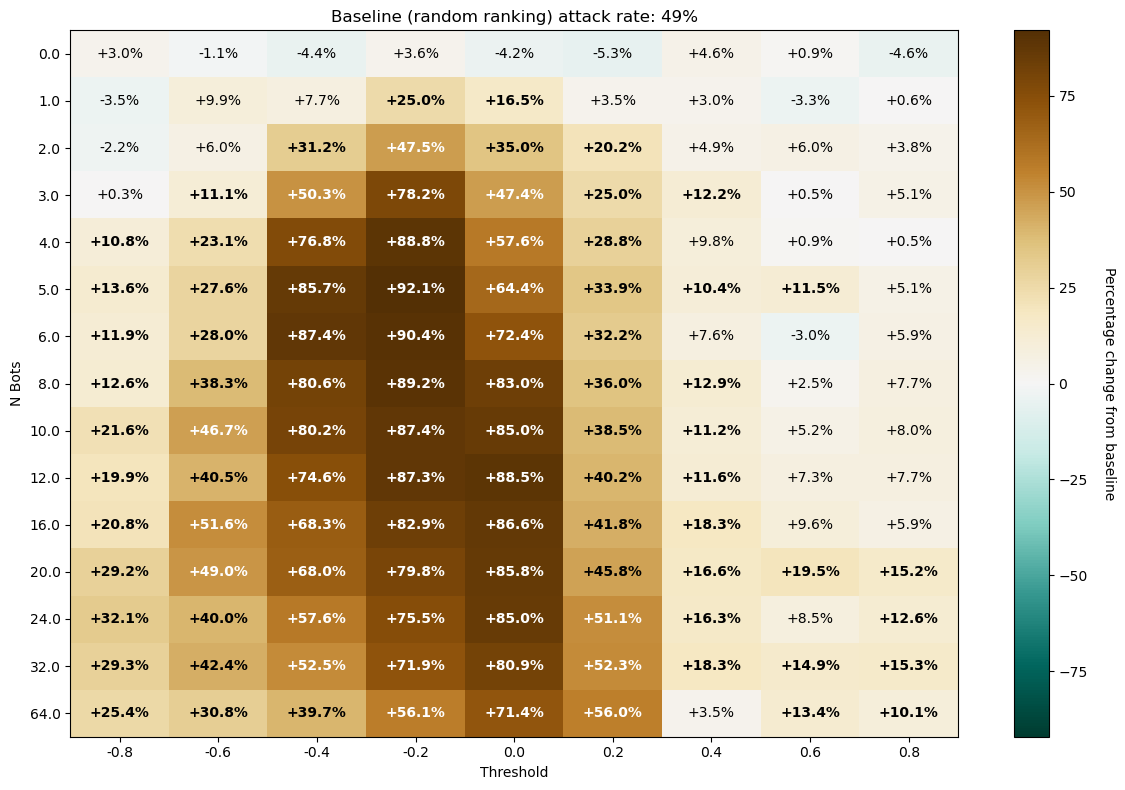

In [45]:
SIRV_baseline_2 = {}
SIRV_baseline_2[(0.3,0,0)] = SIRV_baseline
fig, ax, diffs, baseline = plot_attack_rate_comparison(SIRV_1000, SIRV_baseline_2)

In [47]:
points_of_interest = [(-0.4, 64), (-0.2, 6), (0,0)]

(-0.4, 64)
(-0.2, 6)
(0, 0)


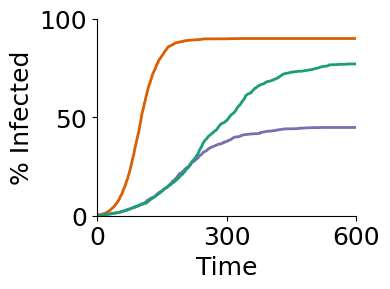

In [48]:
ylabel = ["% Infected"]
names = ["SIR_%"]
Lx, Ly = 4, 3
LW = 2
colors = ['#7570b3','#d95f02','#1b9e77']

fig, ax = plt.subplots(figsize=(Lx, Ly))
for j in range(3):
    infected = SIR_1000[points_of_interest[j]]["I_count"] +SIR_1000[points_of_interest[j]]["R_count"]
    infected = np.median(infected, axis=0)/1000 *100
    ax.plot(infected, color = colors[j], linewidth = LW)
    print(points_of_interest[j])
    #print(infected)
ax.set_xlabel("Time", fontsize = 18)
ax.set_ylabel(ylabel[0], fontsize = 18)
ax.set_xticks([1000, 1300, 1600])
ax.set_xticklabels([0, 300, 600], fontsize = 18)
ax.set_xlim(1000, 1600)
ax.set_ylim(0, 100)
ax.set_yticks([0,50,100])
ax.set_yticklabels([0,50,100], fontsize = 18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(f"figures/{names[0]}.pdf")

(-0.4, 64)
(-0.2, 6)
(0, 0)


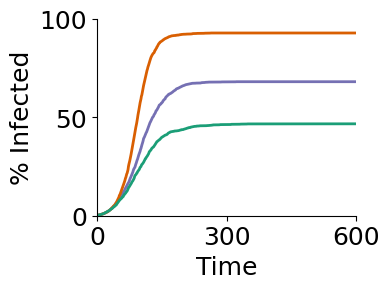

In [49]:
ylabel = ["% Infected"]
names = ["SIRV_%"]
Lx, Ly = 4, 3
LW = 2
colors = ['#7570b3','#d95f02','#1b9e77']

fig, ax = plt.subplots(figsize=(Lx, Ly))
for j in range(3):
    infected = SIRV_1000[points_of_interest[j]]["I_count"] +SIRV_1000[points_of_interest[j]]["R_count"]
    infected = np.median(infected, axis=0)/1000 *100
    ax.plot(infected, color = colors[j], linewidth = LW)
    print(points_of_interest[j])
    #print(infected)
ax.set_xlabel("Time", fontsize = 18)
ax.set_ylabel(ylabel[0], fontsize = 18)
ax.set_xticks([1000, 1300, 1600])
ax.set_xticklabels([0, 300, 600], fontsize = 18)
ax.set_xlim(1000, 1600)
ax.set_ylim(0, 100)
ax.set_yticks([0,50,100])
ax.set_yticklabels([0,50,100], fontsize = 18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(f"figures/{names[0]}.pdf")

(-0.4, 64)
(-0.2, 6)
(0, 0)


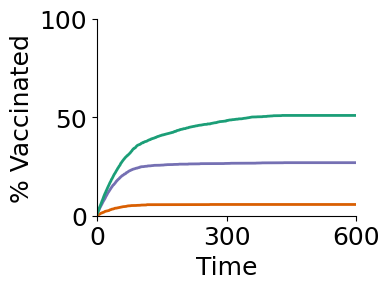

In [50]:
ylabel = ["% Vaccinated"]
names = ["SIRV_vaccinated_%"]
Lx, Ly = 4, 3
LW = 2
colors = ['#7570b3','#d95f02','#1b9e77']

fig, ax = plt.subplots(figsize=(Lx, Ly))
for j in range(3):
    infected = 1000- SIRV_1000[points_of_interest[j]]["S_count"] - SIRV_1000[points_of_interest[j]]["I_count"] - SIRV_1000[points_of_interest[j]]["R_count"]
    infected = np.median(infected, axis=0)/1000 *100
    ax.plot(infected, color = colors[j], linewidth = LW)
    print(points_of_interest[j])
    #print(infected)
ax.set_xlabel("Time", fontsize = 18)
ax.set_ylabel(ylabel[0], fontsize = 18)
ax.set_xticks([1000, 1300, 1600])
ax.set_xticklabels([0, 300, 600], fontsize = 18)
ax.set_xlim(1000, 1600)
ax.set_ylim(0, 100)
ax.set_yticks([0,50,100])
ax.set_yticklabels([0,50,100], fontsize = 18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(f"figures/{names[0]}.pdf")

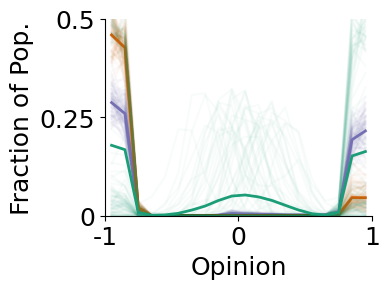

In [ ]:
consolidated_data_list = [SIR_1000[(-0.4,64)], SIR_1000[(-0.2,6)], SIR_1000[(0,0)]]
bin_centers = np.arange(-0.95, 1.0, 0.1)
fig, ax = plt.subplots(figsize=(4, 3))
for i in range(3):
    subdata = consolidated_data_list[i]
    Last_tstep = subdata['opinion_bins'][:, -1, :]
    med = np.median(Last_tstep, axis=0)
    for j in range(100):#len(subdata['opinion_bins'][:, -1, :])):
        ax.plot(bin_centers, Last_tstep[j,:], color = colors[i], alpha = 0.03)#
    ax.plot(bin_centers, med[:], color = colors[i], linewidth = 2)
ax.set_xlim(-1, 1)
ax.set_ylim(0, 0.5)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([0, 0.25, 0.5])
ax.set_xticklabels([-1, 0, 1], fontsize = 18)
ax.set_yticklabels([0, 0.25, 0.5], fontsize = 18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Opinion", fontsize = 18)
ax.set_ylabel("Fraction of Pop.", fontsize = 18)
fig.tight_layout()
fig.savefig("figures/opinion_distribution_SIR.pdf")

Processing 135 parameter combinations...
  1/135: threshold=-0.8, n_bots=0.0
    -> Convergence time: 3025.0
  2/135: threshold=-0.6, n_bots=0.0
    -> Convergence time: 2600.5
  3/135: threshold=-0.4, n_bots=0.0
    -> Convergence time: 2810.0
  4/135: threshold=-0.2, n_bots=0.0
    -> Convergence time: 2980.0
  5/135: threshold=0.0, n_bots=0.0
    -> Convergence time: 2489.5
  6/135: threshold=0.2, n_bots=0.0
    -> Convergence time: 3536.0
  7/135: threshold=0.4, n_bots=0.0
    -> Convergence time: 3237.0
  8/135: threshold=0.6, n_bots=0.0
    -> Convergence time: 2836.0
  9/135: threshold=0.8, n_bots=0.0
    -> Convergence time: 3329.0
  10/135: threshold=-0.8, n_bots=1.0
    -> Convergence time: 2796.0
  11/135: threshold=-0.6, n_bots=1.0
    -> Convergence time: 2483.5
  12/135: threshold=-0.4, n_bots=1.0
    -> Convergence time: 2190.0
  13/135: threshold=-0.2, n_bots=1.0
    -> Convergence time: 2008.0
  14/135: threshold=0.0, n_bots=1.0
    -> Convergence time: 2599.0
  15/135

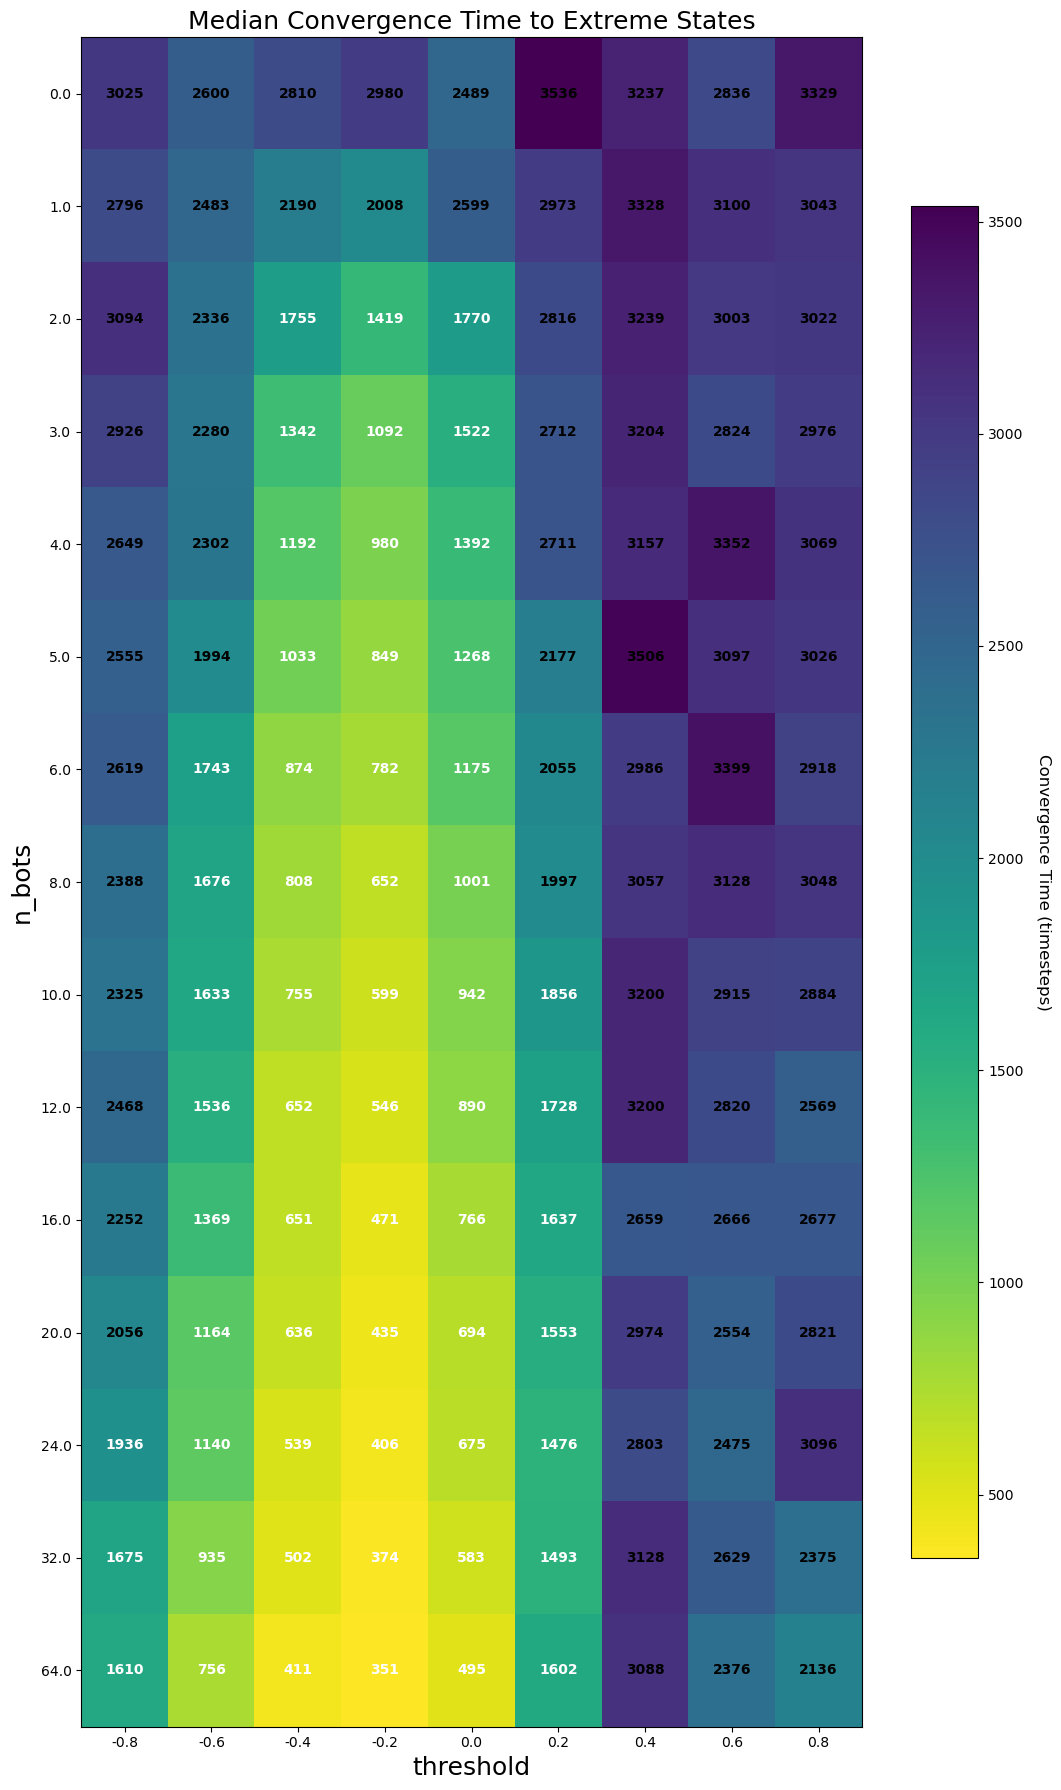

In [57]:
fig, ax, convergence_matrix = plot_convergence_comparison(SIR_1000, 'threshold', 'n_bots')

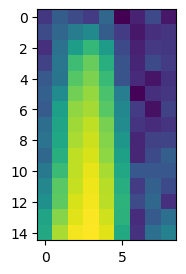

In [59]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.imshow(convergence_matrix, cmap = 'viridis_r')